In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler


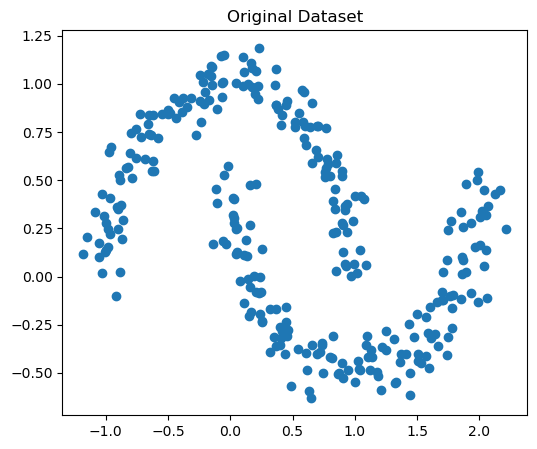

In [2]:
# Create Dataset
X, y = make_moons(n_samples=300, noise=0.08, random_state=42)

# Plot dataset
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1])
plt.title("Original Dataset")
plt.show()


In [4]:
# Scale Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]


array([[ 0.18122939, -1.22454431],
       [ 1.70255099, -0.77872801],
       [-0.70167944,  0.40071894],
       [ 0.4633842 ,  0.02341591],
       [ 0.78038117, -1.50309369]])

In [5]:
# Apply DBSCAN
dbscan = DBSCAN(eps=0.3, min_samples=5)

clusters = dbscan.fit_predict(X_scaled)

clusters[:10]


array([0, 0, 0, 1, 0, 0, 0, 1, 1, 0])

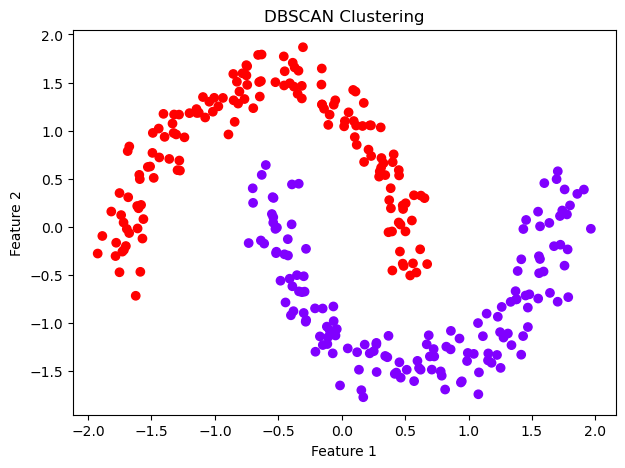

In [6]:
# Plot Clusters
plt.figure(figsize=(7,5))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=clusters,
    cmap='rainbow'
)

plt.title("DBSCAN Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


In [7]:
# Unique cluster labels
unique_clusters = np.unique(clusters)

print("Cluster Labels:", unique_clusters)

# Number of clusters excluding noise
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)

print("Number of Clusters:", n_clusters)

# Number of noise points
noise_points = list(clusters).count(-1)

print("Noise Points:", noise_points)


Cluster Labels: [0 1]
Number of Clusters: 2
Noise Points: 0
